<a href="https://colab.research.google.com/github/suraj76543/DL-24f1001765-notebook-t12026/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers torch pillow datasets

In [ ]:
!pip install --no-deps unsloth
!pip install bitsandbytes accelerate peft trl triton cut_cross_entropy
!pip install sentencepiece protobuf datasets huggingface_hub hf_transfer


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.1/381.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 518.9/518.9 kB 28.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth 2026.1.2 requires tyro, which is not installed.
unsloth 2026.1.2 requires unsloth_zoo>=2026.1.2, which is not installed.
unsloth 2026.1.2 requires xformers>=0.0.27.post2; ("linux" in sys_platform or sys_platform == "win32") and (platform_machine == "AMD64" or platform_machine == "x86_64"), which is not installed.
unsloth 2026.1.2 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.0.0 which is incompatible.
unsloth 2026.1.2 requires trl!=0.19.0,<=0.24.0,>=0.18.2, but you

In [ ]:
!pip install unsloth_zoo
from unsloth import FastVisionModel
import torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 18.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Su

In [ ]:
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit"
]

In [ ]:
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
    device_map="auto",
)


==((====))==  Unsloth 2026.1.2: Fast Qwen2_Vl patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.90G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,

    r=16,
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    random_state = 3407,
    use_rslora=False,
    loftq_config=None
)

Unsloth: Making `model.base_model.model.model.visual` require gradients


In [ ]:
from torch.utils.data import Dataset


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

class IM2LatexDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir

        # auto-detect txt location
        if os.path.exists(os.path.join(root_dir, "corresponding_png_images.txt")):
            base = root_dir
        elif os.path.exists(os.path.join(root_dir, "data", "corresponding_png_images.txt")):
            base = os.path.join(root_dir, "data")
        else:
            raise FileNotFoundError("Could not find corresponding_png_images.txt")

        self.base = base

        with open(os.path.join(base, "corresponding_png_images.txt")) as f:
            self.image_files = [l.strip() for l in f]

        with open(os.path.join(base, "final_png_formulas.txt")) as f:
            self.formulas = [l.strip() for l in f]

        assert len(self.image_files) == len(self.formulas)

    def __len__(self):
        return len(self.formulas)

    def __getitem__(self, idx):
        image_path = os.path.join(
            self.base,
            "generated_png_images",
            self.image_files[idx]
        )
        image = Image.open(image_path).convert("RGB")

        return {
            "image": image,
            "formula": self.formulas[idx],
        }


In [ ]:
!mkdir -p /content/datasets


In [ ]:
!unzip -q "/content/drive/MyDrive/IMG2LaTeX Zip.zip" -d /content/datasets


In [ ]:
!ls /content/datasets


PRINTED_TEX_230k


In [ ]:
!ls /content/datasets/PRINTED_TEX_230k


230k.json		      final_png_formulas.txt
corresponding_png_images.txt  generated_png_images


In [ ]:
root_dir = "/content/datasets/PRINTED_TEX_230k"


In [ ]:
dataset = IM2LatexDataset("/content/datasets/PRINTED_TEX_230k")
dataset[0]


{'image': <PIL.Image.Image image mode=RGB size=200x20>,
 'formula': 'R _ { 1 2 } K _ { 1 } R _ { 2 1 } d K _ { 2 } = d K _ { 2 } R _ { 1 2 } K _ { 1 } R _ { 1 2 } ^ { - 1 } ,'}

In [ ]:
instruction = "Write the LaTeX representation for this image."

def convert_to_conversation(sample):
    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": instruction},
                    {"type": "image", "image": sample["image"]}
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": sample["formula"]}
                ],
            },
        ]
    }


In [ ]:
sample = dataset[0]
conv = convert_to_conversation(sample)
conv


{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=200x20>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'R _ { 1 2 } K _ { 1 } R _ { 2 1 } d K _ { 2 } = d K _ { 2 } R _ { 1 2 } K _ { 1 } R _ { 1 2 } ^ { - 1 } ,'}]}]}

In [ ]:
train_size = 100
test_size  = 20

train_dataset = [convert_to_conversation(dataset[i]) for i in range(train_size)]
test_dataset  = [
    convert_to_conversation(dataset[i])
    for i in range(train_size, train_size + test_size)
]


In [ ]:
from unsloth import UnslothVisionDataCollator


In [ ]:
data_collator = UnslothVisionDataCollator(
    model = model,
    processor = tokenizer
)


Unsloth: Model does not have a default image size - using 512


In [ ]:
from transformers import TrainingArguments, Trainer


In [ ]:
training_args = TrainingArguments(
    output_dir="./vision2tex",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    num_train_epochs=1,
    logging_steps=10,
    save_steps=200,
    fp16=True,
    remove_unused_columns=False,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,   # make sure this is correct
    data_collator=data_collator,
)


In [ ]:
trainer.train()


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 100 | Num Epochs = 1 | Total steps = 13
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 50,855,936 of 8,342,231,552 (0.61% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss


Step,Training Loss
10,1.208800


TrainOutput(global_step=13, training_loss=1.2148014582120454, metrics={'train_runtime': 202.1368, 'train_samples_per_second': 0.495, 'train_steps_per_second': 0.064, 'total_flos': 592371474819072.0, 'train_loss': 1.2148014582120454, 'epoch': 1.0})

In [ ]:
FastVisionModel.for_inference(model)

sample = dataset[1]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": instruction},
        ],
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt"
)

inputs = tokenizer(
    images=sample["image"],
    text=inputs,
    return_tensors="pt"
).to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=256,
    do_sample=False,
)

decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

# extract only the assistant's LaTeX part
latex = decoded.split("assistant")[-1].strip()

# remove $$ if present
latex = latex.replace("$$", "").strip()

print(latex)



E _ { n } - E _ { m } = { \frac { \lambda ( n ^ { 2 } y ^ { 2 } - m ^ { 2 } y ^ { 2 } ) } { y ^ { 2 } } }


In [ ]:
def image_to_latex(image):
    FastVisionModel.for_inference(model)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": instruction},
            ],
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    )

    inputs = tokenizer(
        images=image,
        text=prompt,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [ ]:
!find /content/datasets -name "000a20147419b28.png"


/content/datasets/PRINTED_TEX_230k/generated_png_images/000a20147419b28.png


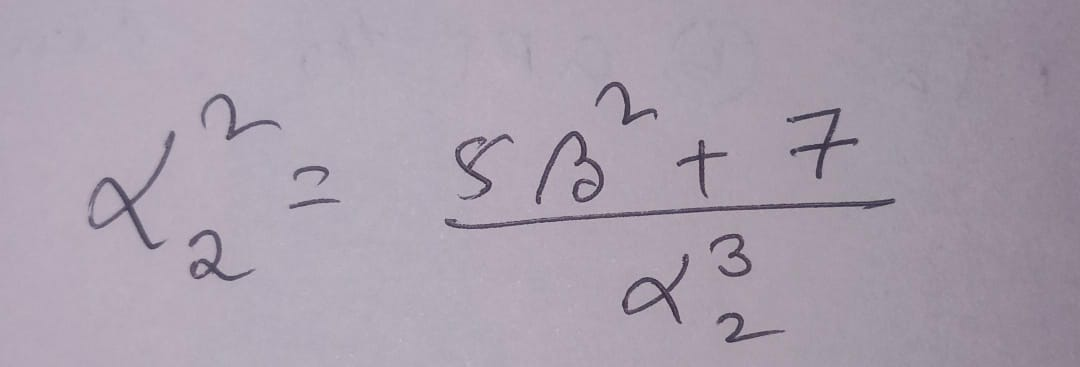

In [ ]:
from PIL import Image
from IPython.display import display

#image_path = "/content/datasets/PRINTED_TEX_230k/generated_png_images/000a20147419b28.png"
image_path = "/test 1.jpeg"
image = Image.open(image_path).convert("RGB")
display(image)


In [ ]:
latex_output = image_to_latex(image)
latex_output = latex_output.split("assistant")[-1]
latex_output = latex_output.replace("$$", "").strip()
print(latex_output)


x _ { 2 } ^ { 2 } = \frac { 5 \beta ^ { 2 } + 7 } { x _ { 2 } ^ { 3 } }


In [ ]:
model.save_pretrained("model_save")
tokenizer.save_pretrained("model_save")

[]

In [ ]:
model, tokenizer = FastVisionModel.from_pretrained(
    "model_save",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
    device_map="auto",
)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,

    r=16,
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    random_state = 3407,
    use_rslora=False,
    loftq_config=None
)

In [ ]:
import re

def normalize_latex(tex):
    tex = tex.lower()
    tex = tex.replace("$$", "")
    tex = tex.replace("\\,", "")
    tex = tex.replace("\\!", "")
    tex = tex.replace("\\left", "").replace("\\right", "")
    tex = re.sub(r"\s+", "", tex)     # remove spaces
    tex = re.sub(r"[{}]", "", tex)    # remove braces
    return tex


In [ ]:
preds = []
refs  = []

for i in range(len(test_dataset)):
    sample = test_dataset[i]

    image = sample["messages"][0]["content"][1]["image"]
    gt    = sample["messages"][1]["content"][0]["text"]

    pred = image_to_latex(image)

    preds.append(normalize_latex(pred))
    refs.append(normalize_latex(gt))


In [ ]:
!pip install -q sacrebleu


In [ ]:
!pip install -q python-Levenshtein


In [ ]:
# 1. Exact Match Accuracy (EMA)
def exact_match_accuracy(preds, refs):
    return sum(p == r for p, r in zip(preds, refs)) / len(refs)


# 2. Expression Recognition Rate (ERR)
def normalize_latex(tex):
    tex = tex.replace(" ", "")
    tex = tex.replace("{", "").replace("}", "")
    tex = tex.replace("\\left", "").replace("\\right", "")
    return tex

def expression_recognition_rate(preds, refs):
    return sum(
        normalize_latex(p) == normalize_latex(r)
        for p, r in zip(preds, refs)
    ) / len(refs)


# 3. BLEU score
import sacrebleu

def bleu_score(preds, refs):
    refs = [[r] for r in refs]
    return sacrebleu.corpus_bleu(preds, refs).score


# 4. Normalized Edit Distance (NED)
import Levenshtein
import numpy as np

def normalized_edit_distance(preds, refs):
    return np.mean([
        Levenshtein.distance(p, r) / max(len(r), 1)
        for p, r in zip(preds, refs)
    ])


In [ ]:
ema  = exact_match_accuracy(preds, refs)
err  = expression_recognition_rate(preds, refs)
bleu = bleu_score(preds, refs)
ned  = normalized_edit_distance(preds, refs)

print(f"Exact Match Accuracy (EMA): {ema:.4f}")
print(f"Expression Recognition Rate (ERR): {err:.4f}")
print(f"BLEU Score: {bleu:.2f}")
print(f"Normalized Edit Distance (NED): {ned:.4f}")
